### Прогнозирование SI

Индекс селективности (SI) - ключевая метрика, определяющая баланс между эффективностью и токсичностью.

In [1]:
# --- АВТОНОМНЫЙ БЛОК ПОДГОТОВКИ ДАННЫХ ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных
excel_url = 'https://lms.skillfactory.ru/asset-v1:SkillFactory+MIFIML-2sem+2025+type@asset+block@%D0%94%D0%B0%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B4%D0%BB%D1%8F_%D0%BA%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%BE%D0%B8__%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%9C%D0%9E.xlsx'
df = pd.read_excel(excel_url)
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.dropna()

targets = ['IC50, mM', 'CC50, mM', 'SI']
X = df.drop(columns=targets)

# 2. Удаление константных признаков
constant_features = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_features)

# 3. Масштабирование
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# 4. Формирование списков для фильтрации (Ablation Study)
# Пирсон
corr_matrix = X_scaled.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_85 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
to_drop_90 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.90)]
to_drop_95 = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

# Спирмен
corr_matrix_spearman = X_scaled.corr(method='spearman').abs()
upper_tri_spearman = corr_matrix_spearman.where(np.triu(np.ones(corr_matrix_spearman.shape), k=1).astype(bool))
to_drop_spearman_85 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.85)]
to_drop_spearman_90 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.90)]
to_drop_spearman_95 = [column for column in upper_tri_spearman.columns if any(upper_tri_spearman[column] > 0.95)]

# Квазиконстанты (>95%)
QUASI_CONSTANT_THRESHOLD = 0.95
quasi_constant_features = []
for col in X_scaled.columns:
    if X_scaled[col].value_counts(normalize=True).values[0] > QUASI_CONSTANT_THRESHOLD:
        quasi_constant_features.append(col)

print("✅ Данные успешно загружены и подготовлены на лету!")
# ---------------------------------------------------

✅ Данные успешно загружены и подготовлены на лету!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.8 MB/s eta 0:00:00
Запуск эксперимента с Linear Regression для log(SI)...


,Pearson_Thr,Drop_Spearman,Drop_Quasi,Num_Features,R2,MAE,RMSE
0,0.85,Yes,Yes,95,1.601000e-01,1.10,1.49
2,0.85,No,Yes,99,1.442000e-01,1.11,1.51
4,0.9,Yes,Yes,100,1.297000e-01,1.11,1.52
8,0.95,Yes,Yes,100,1.297000e-01,1.11,1.52
12,No Drop,Yes,Yes,100,1.297000e-01,1.11,1.52
6,0.9,No,Yes,113,1.026000e-01,1.12,1.54
10,0.95,No,Yes,127,3.970000e-02,1.11,1.59
14,No Drop,No,Yes,158,-7.380000e-02,1.11,1.69
11,0.95,No,No,159,-6.078153e+04,29.46,401.18
3,0.85,No,No,131,-4.812651e+05,80.92,1128.86


Лучший результат Linear Regression (log SI): R2 = 0.1601

Запуск эксперимента с Random Forest для log(SI)...


,Pearson_Thr,Drop_Spearman,Drop_Quasi,Num_Features,R2,MAE,RMSE
10,0.95,No,Yes,127,0.3774,0.94,1.28
11,0.95,No,No,159,0.3764,0.94,1.28
6,0.9,No,Yes,113,0.3763,0.95,1.29
2,0.85,No,Yes,99,0.3753,0.94,1.29
7,0.9,No,No,145,0.3746,0.95,1.29
3,0.85,No,No,131,0.3730,0.95,1.29
5,0.9,Yes,No,132,0.3722,0.95,1.29
9,0.95,Yes,No,132,0.3722,0.95,1.29
13,No Drop,Yes,No,132,0.3722,0.95,1.29
14,No Drop,No,Yes,158,0.3717,0.95,1.29


Лучший результат базового Random Forest (log SI): R2 = 0.3774

Запуск эксперимента с XGBoost для log(SI)...


,Pearson_Thr,Drop_Spearman,Drop_Quasi,Num_Features,R2,MAE,RMSE
3,0.85,No,No,131,0.3485,0.93,1.31
1,0.85,Yes,No,127,0.3451,0.93,1.32
2,0.85,No,Yes,99,0.3413,0.93,1.32
15,No Drop,No,No,192,0.3375,0.95,1.32
0,0.85,Yes,Yes,95,0.3373,0.95,1.32
14,No Drop,No,Yes,158,0.3314,0.94,1.33
5,0.9,Yes,No,132,0.3247,0.96,1.34
9,0.95,Yes,No,132,0.3247,0.96,1.34
13,No Drop,Yes,No,132,0.3247,0.96,1.34
11,0.95,No,No,159,0.3178,0.96,1.34


Лучший результат базового XGBoost (log SI): R2 = 0.3485


--- Тонкая настройка лучших моделей с помощью BayesSearchCV ---
Тюнинг Linear Regression...
Тюнинг Random Forest...
Тюнинг XGBoost...

--- Итоговое сравнение лучших моделей для log(SI) (Тюнингованные варианты) ---


,Model,R2,MAE,RMSE
2,XGBoost Bayes Tuned,0.382802,0.931457,1.278379
1,Random Forest Bayes Tuned,0.373434,0.950480,1.288044
0,Linear Regression Tuned,0.160115,1.102563,1.491273


/tmp/ipykernel_10782/1453717481.py:197: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R2', y='Model', data=results_df_si_final, palette='viridis')


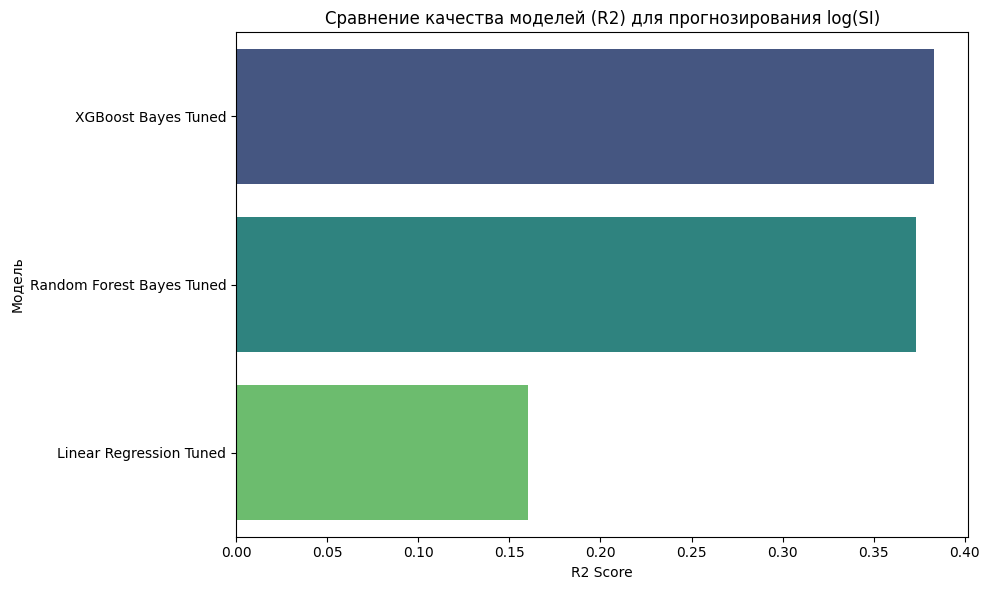

In [2]:
!pip install scikit-optimize
import itertools
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Базовые данные
X_base_exp = X_scaled
# ПРИМЕНЯЕМ ЛОГАРИФМИРОВАНИЕ ИЗ-ЗА ЭКСТРЕМАЛЬНЫХ ВЫБРОСОВ В SI
y_exp_si = np.log1p(df['SI'])

# Функция для оценки
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return {'Model': model_name, 'R2': r2, 'MAE': mae, 'RMSE': rmse}

# Функция фильтрации признаков
def get_filtered_X(X_input, pearson_thr, apply_spearman, drop_quasi):
    cols_to_drop = set()
    if pearson_thr == 0.85:
        cols_to_drop.update(to_drop_85)
    elif pearson_thr == 0.90:
        cols_to_drop.update(to_drop_90)
    elif pearson_thr == 0.95:
        cols_to_drop.update(to_drop_95)
    if apply_spearman:
        cols_to_drop.update(to_drop_spearman_85)
    if drop_quasi:
        cols_to_drop.update(quasi_constant_features)

    cols_to_drop = cols_to_drop.intersection(X_input.columns)
    return X_input.drop(columns=list(cols_to_drop))

# Параметры сетки эксперимента
pearson_thresholds = [0.85, 0.90, 0.95, 1.0]
spearman_flags = [True, False]
quasi_flags = [True, False]

results_si = []

# --- 1. Linear Regression Ablation Study для SI ---
print("Запуск эксперимента с Linear Regression для log(SI)...")
best_lr_r2_si = -float('inf')
best_lr_res_si = None
results_lr_ablation_si = []

for p_thr, s_flag, q_flag in itertools.product(pearson_thresholds, spearman_flags, quasi_flags):
    X_filtered = get_filtered_X(X_base_exp, p_thr, s_flag, q_flag)
    X_tr, X_te, y_tr, y_te = train_test_split(X_filtered, y_exp_si, test_size=0.2, random_state=42)

    lr_model = LinearRegression()
    lr_model.fit(X_tr, y_tr)
    res = evaluate_model(lr_model, X_te, y_te, 'Linear Regression')

    results_lr_ablation_si.append({
        'Pearson_Thr': p_thr if p_thr < 1.0 else 'No Drop',
        'Drop_Spearman': 'Yes' if s_flag else 'No',
        'Drop_Quasi': 'Yes' if q_flag else 'No',
        'Num_Features': X_filtered.shape[1],
        'R2': round(res['R2'], 4),
        'MAE': round(res['MAE'], 2),
        'RMSE': round(res['RMSE'], 2)
    })

    if res['R2'] > best_lr_r2_si:
        best_lr_r2_si = res['R2']
        best_lr_res_si = res
        best_lr_res_si['Model'] = f"LR (Best: P={p_thr}, S={s_flag}, Q={q_flag})"
        best_lr_X_train_si, best_lr_X_test_si = X_tr, X_te
        best_lr_y_train_si, best_lr_y_test_si = y_tr, y_te

lr_ablation_df_si = pd.DataFrame(results_lr_ablation_si).sort_values(by='R2', ascending=False)
display(lr_ablation_df_si)
print(f"Лучший результат Linear Regression (log SI): R2 = {best_lr_r2_si:.4f}\n")

# --- 2. Random Forest Ablation Study для SI ---
print("Запуск эксперимента с Random Forest для log(SI)...")
best_rf_r2_si = -float('inf')
best_rf_res_si = None
best_rf_X_train_si, best_rf_X_test_si = None, None
best_rf_y_train_si, best_rf_y_test_si = None, None
results_rf_ablation_si = []

for p_thr, s_flag, q_flag in itertools.product(pearson_thresholds, spearman_flags, quasi_flags):
    X_filtered = get_filtered_X(X_base_exp, p_thr, s_flag, q_flag)
    X_tr, X_te, y_tr, y_te = train_test_split(X_filtered, y_exp_si, test_size=0.2, random_state=42)

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_tr, y_tr)
    res = evaluate_model(rf_model, X_te, y_te, 'Random Forest')

    results_rf_ablation_si.append({
        'Pearson_Thr': p_thr if p_thr < 1.0 else 'No Drop',
        'Drop_Spearman': 'Yes' if s_flag else 'No',
        'Drop_Quasi': 'Yes' if q_flag else 'No',
        'Num_Features': X_filtered.shape[1],
        'R2': round(res['R2'], 4),
        'MAE': round(res['MAE'], 2),
        'RMSE': round(res['RMSE'], 2)
    })

    if res['R2'] > best_rf_r2_si:
        best_rf_r2_si = res['R2']
        best_rf_res_si = res
        best_rf_res_si['Model'] = f"RF (Best: P={p_thr}, S={s_flag}, Q={q_flag})"
        best_rf_X_train_si, best_rf_X_test_si = X_tr, X_te
        best_rf_y_train_si, best_rf_y_test_si = y_tr, y_te

rf_ablation_df_si = pd.DataFrame(results_rf_ablation_si).sort_values(by='R2', ascending=False)
display(rf_ablation_df_si)
print(f"Лучший результат базового Random Forest (log SI): R2 = {best_rf_r2_si:.4f}\n")

# --- 3. XGBoost Ablation Study для SI ---
print("Запуск эксперимента с XGBoost для log(SI)...")
best_xgb_r2_si = -float('inf')
best_xgb_res_si = None
best_xgb_X_train_si, best_xgb_X_test_si = None, None
best_xgb_y_train_si, best_xgb_y_test_si = None, None
results_xgb_ablation_si = []

for p_thr, s_flag, q_flag in itertools.product(pearson_thresholds, spearman_flags, quasi_flags):
    X_filtered = get_filtered_X(X_base_exp, p_thr, s_flag, q_flag)
    X_tr, X_te, y_tr, y_te = train_test_split(X_filtered, y_exp_si, test_size=0.2, random_state=42)

    xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)
    xgb_model.fit(X_tr, y_tr)
    res = evaluate_model(xgb_model, X_te, y_te, 'XGBoost')

    results_xgb_ablation_si.append({
        'Pearson_Thr': p_thr if p_thr < 1.0 else 'No Drop',
        'Drop_Spearman': 'Yes' if s_flag else 'No',
        'Drop_Quasi': 'Yes' if q_flag else 'No',
        'Num_Features': X_filtered.shape[1],
        'R2': round(res['R2'], 4),
        'MAE': round(res['MAE'], 2),
        'RMSE': round(res['RMSE'], 2)
    })

    if res['R2'] > best_xgb_r2_si:
        best_xgb_r2_si = res['R2']
        best_xgb_res_si = res
        best_xgb_res_si['Model'] = f"XGBoost (Best: P={p_thr}, S={s_flag}, Q={q_flag})"
        best_xgb_X_train_si, best_xgb_X_test_si = X_tr, X_te
        best_xgb_y_train_si, best_xgb_y_test_si = y_tr, y_te

xgb_ablation_df_si = pd.DataFrame(results_xgb_ablation_si).sort_values(by='R2', ascending=False)
display(xgb_ablation_df_si)
print(f"Лучший результат базового XGBoost (log SI): R2 = {best_xgb_r2_si:.4f}\n")

# --- 4. Байесовский поиск гиперпараметров для лучших вариантов моделей ---
print("\n--- Тонкая настройка лучших моделей с помощью BayesSearchCV ---")

# Linear Regression Tuned
print("Тюнинг Linear Regression...")
search_space_lr_si = {'fit_intercept': Categorical([True, False])}
lr_base_si = LinearRegression()
bayes_search_lr_si = BayesSearchCV(estimator=lr_base_si, search_spaces=search_space_lr_si, n_iter=2, cv=3, scoring='r2', random_state=42, n_jobs=-1)
bayes_search_lr_si.fit(best_lr_X_train_si, best_lr_y_train_si)
res_lr_tuned_si = evaluate_model(bayes_search_lr_si.best_estimator_, best_lr_X_test_si, best_lr_y_test_si, 'Linear Regression Tuned')
results_si.append(res_lr_tuned_si)

# Random Forest Tuned
print("Тюнинг Random Forest...")
search_space_rf_si = {'n_estimators': Integer(100, 300), 'max_depth': Integer(10, 30), 'min_samples_split': Integer(2, 10)}
rf_base_si = RandomForestRegressor(random_state=42, n_jobs=-1)
bayes_search_rf_si = BayesSearchCV(estimator=rf_base_si, search_spaces=search_space_rf_si, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
bayes_search_rf_si.fit(best_rf_X_train_si, best_rf_y_train_si)
res_rf_tuned_si = evaluate_model(bayes_search_rf_si.best_estimator_, best_rf_X_test_si, best_rf_y_test_si, 'Random Forest Bayes Tuned')
results_si.append(res_rf_tuned_si)

# XGBoost Tuned
print("Тюнинг XGBoost...")
search_space_xgb_si = {'n_estimators': Integer(100, 300), 'max_depth': Integer(3, 10), 'learning_rate': Real(0.01, 0.2, prior='log-uniform'), 'subsample': Real(0.6, 1.0), 'colsample_bytree': Real(0.6, 1.0)}
xgb_base_si = xgb.XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)
bayes_search_xgb_si = BayesSearchCV(estimator=xgb_base_si, search_spaces=search_space_xgb_si, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
bayes_search_xgb_si.fit(best_xgb_X_train_si, best_xgb_y_train_si)
res_xgb_tuned_si = evaluate_model(bayes_search_xgb_si.best_estimator_, best_xgb_X_test_si, best_xgb_y_test_si, 'XGBoost Bayes Tuned')
results_si.append(res_xgb_tuned_si)

# --- Вывод итоговых результатов ---
print("\n--- Итоговое сравнение лучших моделей для log(SI) (Тюнингованные варианты) ---")
results_df_si_final = pd.DataFrame(results_si).sort_values(by='R2', ascending=False)
display(results_df_si_final)

plt.figure(figsize=(10, 6))
sns.barplot(x='R2', y='Model', data=results_df_si_final, palette='viridis')
plt.title('Сравнение качества моделей (R2) для прогнозирования log(SI)')
plt.xlabel('R2 Score')
plt.ylabel('Модель')
plt.tight_layout()
plt.show()


### Выводы по прогнозированию SI (Индекса селективности):

1. **Необходимость логарифмирования:** Из-за экстремального разброса значений и сильной асимметрии распределения целевой переменной `SI`, пришлось лагорифмировать, что позволило стабилизировать обучение моделей и получить адекватные метрики.
2. **Сравнение алгоритмов:** Как и в предыдущих задачах Random Forest и XGBoost показали значительное превосходство над линейной регрессией ($R^2 \approx 0.38$ против $0.16$).
3. **Сложность задачи:** XGBoost после тонкой настройки смогла объяснить лишь около 38% дисперсии ($R^2 \approx 0.38$). Это говорит о том, что точное предсказание непрерывного значения SI на основе представленных дескрипторов является крайне сложной задачей. Поскольку SI — это производная величина (CC50/IC50), сложная нелинейная природа этой метрики делает задачу регрессии труднорешаемой с высокой точностью.
4. **Влияние отбора признаков (Ablation Study):**
   * **Linear Regression:** Критически зависит от удаления мультиколлинеарных и шумовых признаков.
   * **Ансамбли (RF, XGBoost):** Менее чувствительны к отбору, часто извлекают пользу из полного набора дескрипторов (включая квазиконстантные и сильно скоррелированные), так как алгоритмы внутренне производят отбор и устойчивы к избыточной информации.
5. **Дальнейшие шаги:** Учитывая сложность точного прогноза SI, в реальной практике разработки лекарств часто более целесообразно ставить задачу классификации: например, предсказывать, превышает ли SI заданный порог (допустим, SI > 8), чтобы отсеивать неперспективные молекулы. Именно поэтому следующим шагом мы переходим к задачам классификации.